# EDA Notebook

## 1. Importar librerías necesarias
Importar pandas, numpy, matplotlib y seaborn para el análisis y visualización de datos.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

## 2. Crear el Dataframe
Cargar el archivo CSV.

In [5]:
#Añadir la carpeta raíz del proyecto al path
sys.path.append(os.path.abspath(".."))

from src.io import load_csv

df = load_csv("../data/raw/WBL_Mobility_2026_ds.csv")

## 3. Visualizar las primeras filas del dataset
Mostrar las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [6]:
df.head()

,country_code,country_name,year,wb_region,wb_income_group,overall_mobility_score,legal_frameworks_score,law_can_choose_where_to_live,law_can_travel_internationally,law_can_leave_marital_home,...,sfr_equal_id_document_process,sfr_equal_passport_process,sfr_gender_sensitive_transport_policy,sfr_free_from_govt_mobility_constraints,enforcement_perceptions_score,enf_right_to_choose_where_to_live,enf_right_to_travel_internationally,enf_right_to_leave_marital_home,enf_equal_citizenship_rights,has_enforcement_data
0,AUS,Australia,2026,East Asia & Pacific,High income,100.0,100.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,100.0,4.0,4.0,4.0,4.0,1
1,AUT,Austria,2026,Europe & Central Asia,High income,100.0,100.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,100.0,4.0,4.0,4.0,4.0,1
2,FIN,Finland,2026,Europe & Central Asia,High income,100.0,100.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,100.0,4.0,4.0,4.0,4.0,1
3,ESP,Spain,2026,Europe & Central Asia,High income,100.0,100.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,100.0,4.0,4.0,4.0,4.0,1
4,FRA,France,2026,Europe & Central Asia,High income,100.0,100.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,100.0,4.0,4.0,4.0,4.0,1


## 4. Explorar información general del dataset
Utilizar info() y shape para mostrar información sobre el número de filas, columnas y tipos de datos.

In [7]:
df.info()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   country_code                             201 non-null    object 
 1   country_name                             201 non-null    object 
 2   year                                     201 non-null    int64  
 3   wb_region                                201 non-null    object 
 4   wb_income_group                          201 non-null    object 
 5   overall_mobility_score                   201 non-null    float64
 6   legal_frameworks_score                   201 non-null    float64
 7   law_can_choose_where_to_live             201 non-null    float64
 8   law_can_travel_internationally           201 non-null    float64
 9   law_can_leave_marital_home               201 non-null    float64
 10  law_equal_citizenship_rights             201 non-n

## 5. Describir variables numéricas y categóricas
Usar describe() para variables numéricas y value_counts() para variables categóricas.

In [8]:
# Numerical variables
df_numeric_cols = df.select_dtypes(include=["float64", "int64"])
df_numeric_cols.describe()

# Categorical values (Example for a columnn)
df['wb_region'].value_counts()
df['wb_income_group'].value_counts()
df['country_name'].value_counts()

country_name
Australia             1
Austria               1
Finland               1
Spain                 1
France                1
                     ..
Iraq                  1
Bahrain               1
Afghanistan           1
Sudan                 1
Iran, Islamic Rep.    1
Name: count, Length: 201, dtype: int64

## 6. Visualizar valores nulos y duplicados
Identificar y visualizar la cantidad de valores nulos y filas duplicadas en el dataset.

In [9]:
# Null values
df.isnull().sum()

# Duplicated rows
df.duplicated().sum()

np.int64(0)

## 7. Limpieza y nuevas variables
Limpiar el df y crear las variables nuevas.

In [10]:
from src.cleaning import clean
from src.features import build_features

df = clean(df)
df = build_features(df)

## 8. Análisis univariado de variables numéricas
Realizar histogramas y boxplots para analizar la distribución de las variables numéricas.

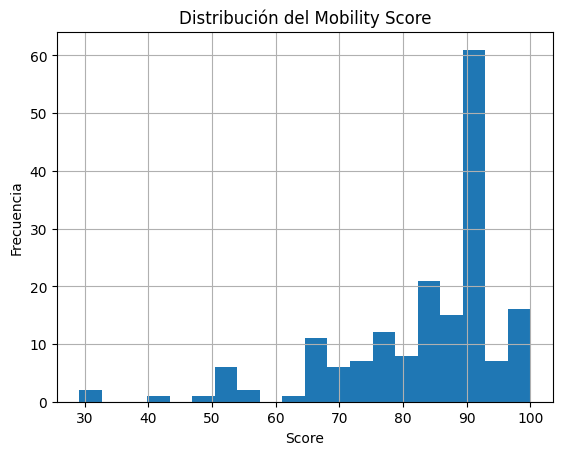

<Figure size 640x480 with 0 Axes>

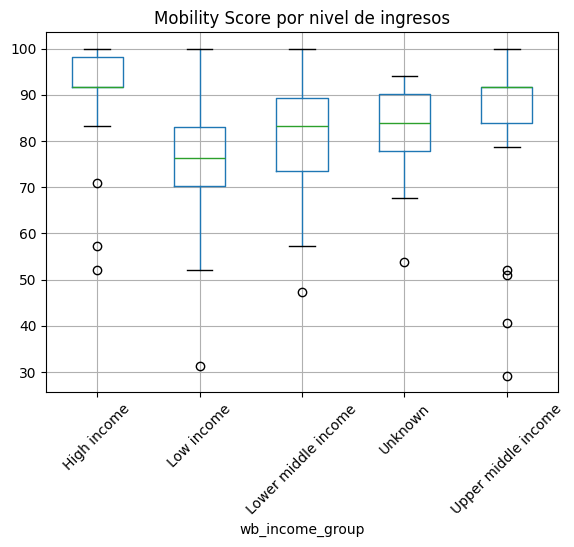

In [11]:
# Histogram for a numerical variable
plt.figure()
df['overall_mobility_score'].hist(bins=20)
plt.title("Distribución del Mobility Score")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot
plt.figure()
df.boxplot(column="overall_mobility_score", by="wb_income_group")
plt.title("Mobility Score por nivel de ingresos")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()


## 9. Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

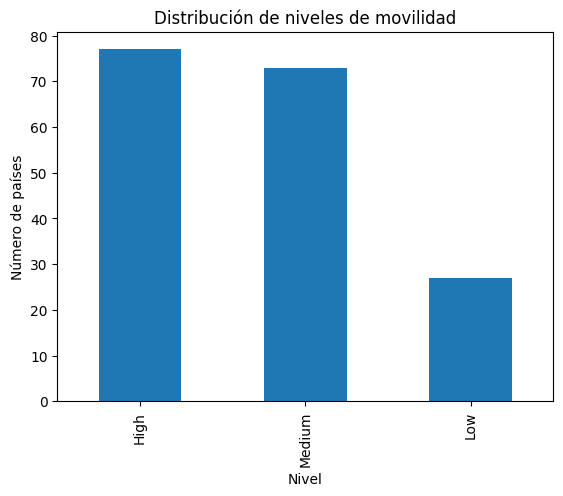

In [12]:
# Bar plot for a categorical variable
plt.figure()
df["mobility_level"].value_counts().plot(kind="bar")
plt.title("Distribución de niveles de movilidad")
plt.xlabel("Nivel")
plt.ylabel("Número de países")
plt.show()

## 10. Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

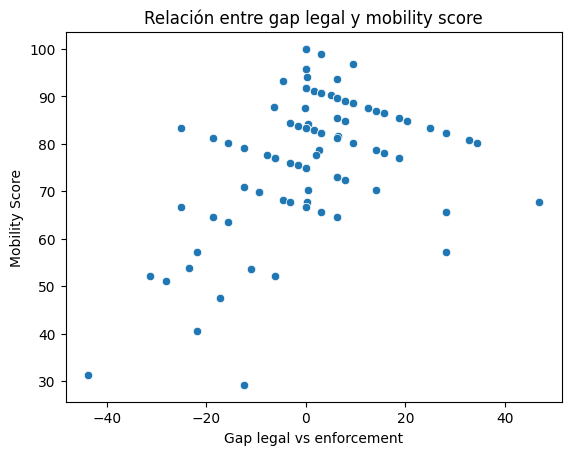

wb_income_group  High income  Low income  Lower middle income  Unknown  \
mobility_level                                                           
High                      36           3                   10        5   
Low                        2           7                   11        3   
Medium                     4          18                   25       10   

wb_income_group  Upper middle income  
mobility_level                        
High                              23  
Low                                4  
Medium                            16  


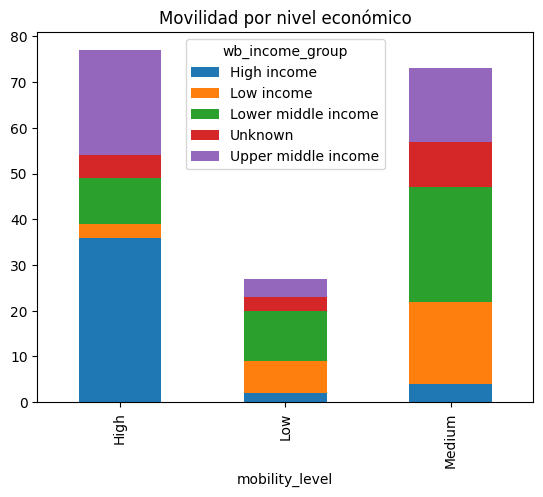

In [13]:
# Scatterplot
plt.figure()
sns.scatterplot(
    x="legal_vs_enforcement_gap",
    y="overall_mobility_score",
    data=df
)
plt.title("Relación entre gap legal y mobility score")
plt.xlabel("Gap legal vs enforcement")
plt.ylabel("Mobility Score")
plt.show()

# Crosstab for two categorical variables   
crosstab = pd.crosstab(df["mobility_level"], df["wb_income_group"])
print(crosstab)

#Representación gráfica de la crosstab
crosstab.plot(kind="bar", stacked=True)
plt.title("Movilidad por nivel económico")
plt.show()

## 11. Visualización de correlaciones
Calcular y visualizar la matriz de correlación entre variables numéricas usando un heatmap.

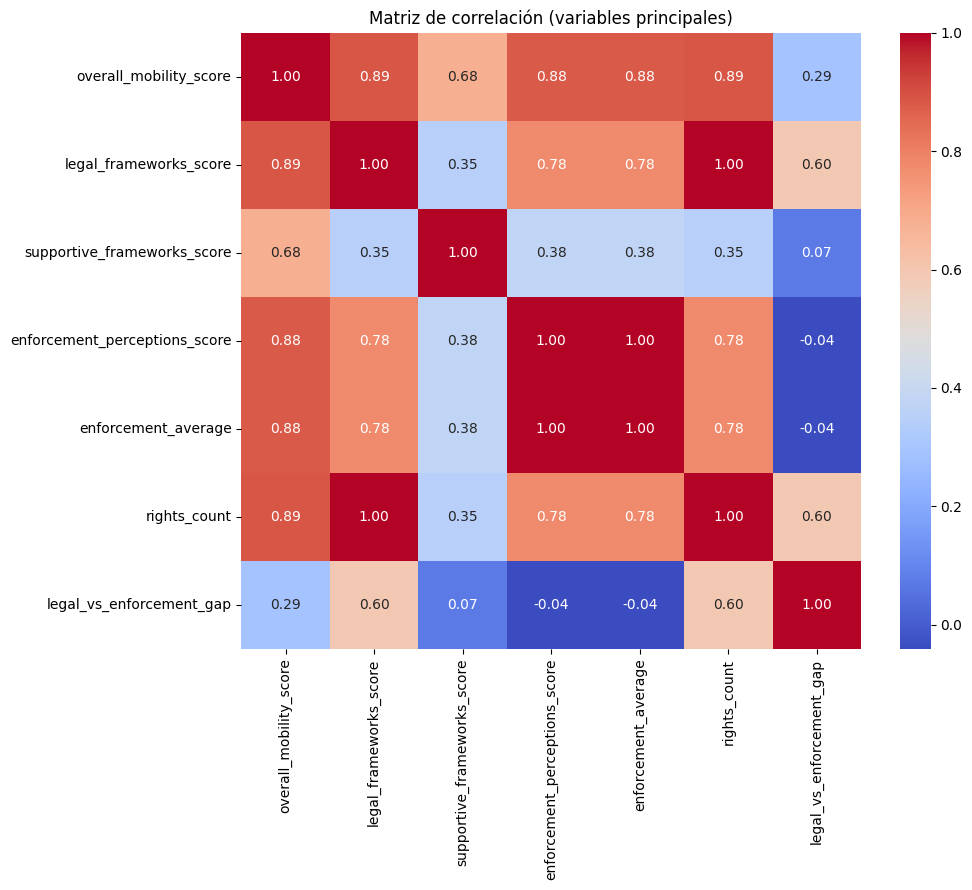

In [14]:
#Matriz de correlación resumida con las variables más importantes
cols = [
    "overall_mobility_score",
    "legal_frameworks_score",
    "supportive_frameworks_score",
    "enforcement_perceptions_score",
    "enforcement_average",
    "rights_count",
    "legal_vs_enforcement_gap"
]

corr = df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación (variables principales)")
plt.show()